In [6]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

First you have to define the state which is the information that will be carried throughtout the graph

TypedDict is a special Dictionary where you can tell what will be the datatypes.

In [14]:
# Define the state structure for BMI calculation
class BMIState(TypedDict):

    height: float  # in meters
    weight: float  # in kilograms
    bmi: float     # Body Mass Index
    bmi_category: str  # BMI Category

In [15]:
def calculate_bmi(state: BMIState) -> BMIState:
    
    """Calculate BMI and update the state."""

    height = state['height']
    weight = state['weight']
    
    bmi = weight / (height ** 2)
    state['bmi'] = bmi
    
    return state

In [16]:
def label_category(state: BMIState) -> BMIState:
    
    """Label BMI category based on calculated BMI."""
    
    bmi = state['bmi']
    
    if bmi < 18.5:
        category = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        category = 'Normal weight'
    elif 25 <= bmi < 29.9:
        category = 'Overweight'
    else:
        category = 'Obesity'
    
    state['bmi_category'] = category
    
    return state

In [17]:
# Initialize the StateGraph with the BMIState structure

graph = StateGraph(BMIState)

# Add nodes to the graph

graph.add_node('calculate_bmi',calculate_bmi) # name of the node and the function to execute
graph.add_node('label_bmi_category',label_category)
# Add edges to the graph

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label_bmi_category')
graph.add_edge('label_bmi_category',END)
# Compile the graph
workflow=graph.compile()



In [18]:
# Execute the graph with sample data

initial_state = {
    'height': 1.75,  # meters
    'weight': 70.0,  # kilograms
    'bmi': 0.0       # will be calculated ,optional to add
}

final_state = workflow.invoke(initial_state)

In [19]:
print("Final State:", final_state)

Final State: {'height': 1.75, 'weight': 70.0, 'bmi': 22.857142857142858, 'bmi_category': 'Normal weight'}


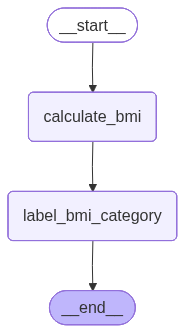

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())